In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.stats as sts
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter, MaxNLocator

1\. **Kernel Density Estimate**

a) Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)

b)
* for every element of x, create a gaussian with the mean corresponding to the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method.

In [2]:
N, mu, sigma = 500, 0.5, 0.5
x = npr.normal(size=N, loc=mu, scale=sigma)
xmin  = mu-5*sigma
xmax  = mu+5*sigma
bin_n = int(np.sqrt(N))
range_size = [x.min()-1, x.max()+1]

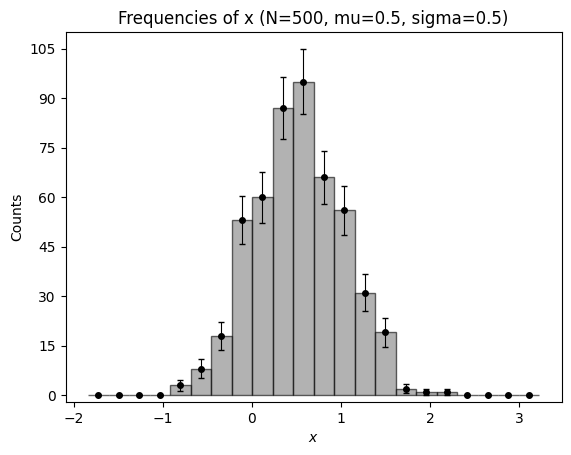

In [3]:
fig, ax = plt.subplots()
n, bin_edges, _ = ax.hist(x, bins=bin_n, range=range_size, alpha=0.6, color='grey', edgecolor='black')
bin_width = bin_edges[1]-bin_edges[0]
bin_centres = 0.5*(bin_edges[1:]+bin_edges[:-1])
poisson_unc = np.where(n>0, np.sqrt(n), 0)

ax.set_xlabel('$x$')
ax.set_ylabel('Counts')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(-2, 110)
ax.set_title(f'Frequencies of x (N={N}, mu={mu}, sigma={sigma})')
ax.errorbar(x=bin_centres, y=n, yerr=poisson_unc, fmt='o', capsize=2, elinewidth=0.8, capthick=1, ms=4, color='black')
plt.show()

In [4]:
# for every element of x, create a gaussian with the mean 
# corresponding to the element value and std as a parameter that can be tuned
def std_par(x, std=x.std(), c=1.06, p=-1/5.):
    return c * std * x.size**(p)

x_range = np.linspace(start=x.min()-1, stop=x.max()+1, num=N)

gauss = np.array([sts.norm.pdf(x=x_range, loc=x_i, scale=std_par(x)) for x_i in x])
gauss.shape

(500, 500)

(-0.05, 2.831935953308687)

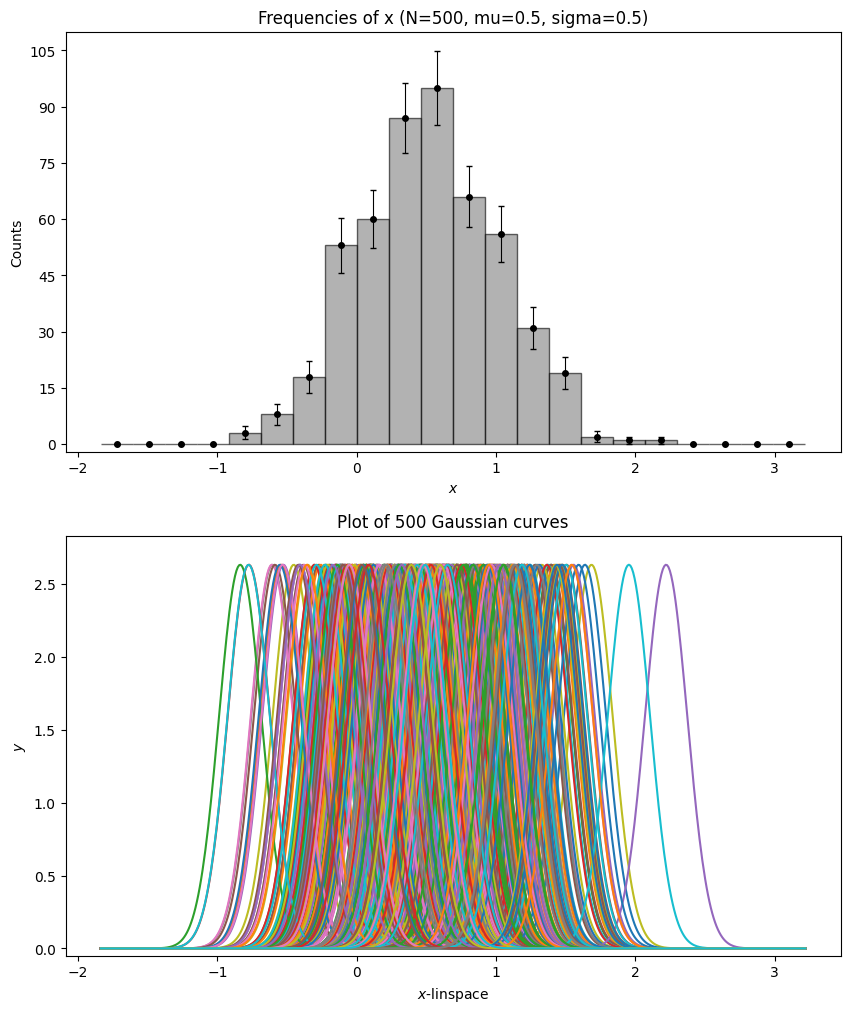

In [5]:
# In a separate plot (to be placed beside the original histogram), 
# plot all the gaussian functions so obtained
fig, ax = plt.subplots(2, figsize=(10, 12))

# HIST PLOT
n, bin_edges, _ = ax[0].hist(x, bins=int(np.sqrt(N)), range=[x.min()-1, x.max()+1], alpha=0.6, color='grey', edgecolor='black')
bin_centres = 0.5*(bin_edges[1:]+bin_edges[:-1])
poisson_unc = np.where(n>0, np.sqrt(n), 0)
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('Counts')
ax[0].yaxis.set_major_locator(MaxNLocator(integer=True))
ax[0].set_ylim(-2, 110)
ax[0].set_title(f'Frequencies of x (N={N}, mu={mu}, sigma={sigma})')
ax[0].errorbar(x=bin_centres, y=n, yerr=poisson_unc, fmt='o', capsize=2, elinewidth=0.8, capthick=1, ms=4, color='black')

# GAUSS PLOT
for i in range(len(gauss)): ax[1].plot(x_range, gauss[i])
ax[1].set_title(f"Plot of {len(gauss)} Gaussian curves")
ax[1].set_xlabel("$x$-linspace")
ax[1].set_ylabel("$y$")
ax[1].set_ylim(-0.05, gauss[0].max()+0.2)


+ The Gaussians represent probability distributions centered at each x_i in x. Their sum produces a new gaussian representing a smooth estimate of the density of x.
+ To ensure that the new Gaussian is normalized to 1 we must divide by the integral of the sum of the Gaussian over the whole x_range.
+ We can rescale the function to match the histogram counts by multiplying it by the total area under all bins, that is ```N*bin_width```

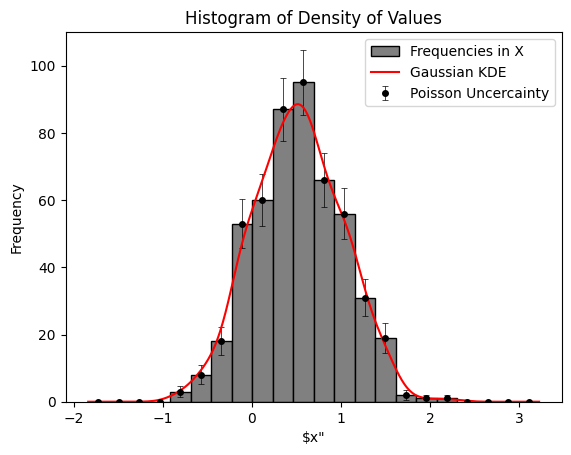

In [6]:
# Sum (with np.sum()) all the gaussian functions and normalize the result 
# such that the integral matches the integral of the original histogram. 
# For that you can use the `scipy.integrate.trapz()` method.
gauss_sum = np.sum(gauss, axis=0)
gauss_sum /= scipy.integrate.trapezoid(y=gauss_sum, x=x_range)
gauss_sum *= N*bin_width
plt.figure()

plt.hist(x, bins=bin_n, range=range_size, color='gray', edgecolor='black', label='Frequencies in X')
plt.errorbar(x=bin_centres, y=n, yerr=poisson_unc, fmt='o', color='black', elinewidth=0.5, ecolor='black', capsize=2, capthick=0.5, ms=4, label="Poisson Uncercainty")
plt.plot(x_range, gauss_sum, color='red', label='Gaussian KDE')
plt.legend()
plt.ylabel('Frequency')
plt.xlabel('$x"')
plt.title('Histogram of Density of Values')
plt.show()


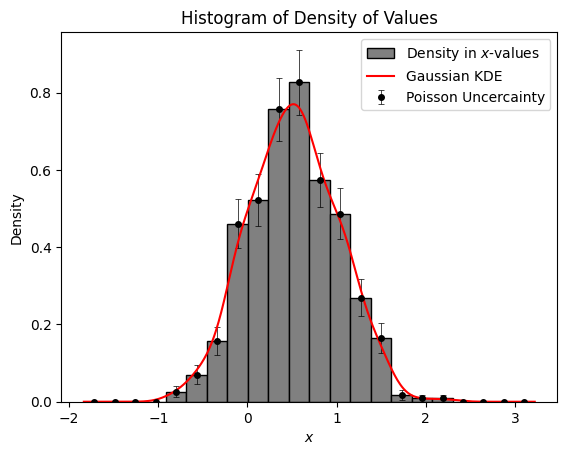

In [7]:
plt.figure()
plt.hist(x, bins=bin_n, range=range_size, density=True, color='gray', edgecolor='black', label='Density in $x$-values')
plt.errorbar(x=bin_centres, y=n/(N*bin_width), yerr=poisson_unc/(N*bin_width), fmt='o', color='black', elinewidth=0.5, ecolor='black', capsize=2, capthick=0.5, ms=4, label="Poisson Uncercainty")
plt.plot(x_range, gauss_sum/(N*bin_width), color='red', label='Gaussian KDE')
plt.legend()
plt.ylabel('Density')
plt.xlabel('$x$')
plt.title('Histogram of Density of Values')
plt.show()

2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

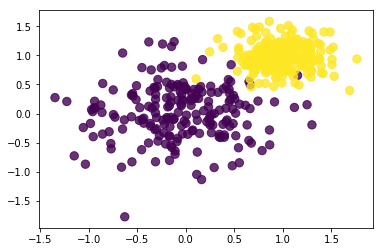

In [8]:
#! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

In [9]:
# Write a function that generate a 2D datasets of 2 categories. 
# Each category should distribute as a 2D gaussian with a given mean and std

# To generate a multivariate dataset we firstly need to compute the mean vector MU
# and variance-covariance matrix SIGMA
# In this case:
#   MU is a 2D vector representing the mean of the observations for each dimension 
#   for a category
#   SIGMA is a 2x2 matrix representing the variance and covariance correlation terms of the two dimensions
# Thus, for each category we weill create a list of 2D random variables of size N
# Finally the two categories are stacked in a single array and 

def dataset_gen(mean0:list, mean1: float, cov0: list, cov1:list, size: int):
    x_0 = sts.multivariate_normal.rvs(mean=mean0, cov=cov0, size=size, random_state=2)
    x_1 = sts.multivariate_normal.rvs(mean=mean1, cov=cov1, size=size, random_state=2)
    
    x_0 = np.array(x_0)
    x_1 = np.array(x_1)
    
    return x_0, x_1

mean0 = npr.uniform(-10, 10, size=2).tolist()
mean1 = npr.uniform(-10, 10, size=2).tolist()


def generate_spd_matrix(n):
    A = npr.rand(n, n)
    return np.dot(A, A.transpose())

cov0 = generate_spd_matrix(2)
cov1 = generate_spd_matrix(2)

print("cov0:", cov0)
print("cov1:", cov1)

x0, x1 = dataset_gen(
    mean0=mean0, 
    mean1=mean1, 
    cov0=cov0, 
    cov1=cov1, 
    size=500
    )

cov0: [[0.12795386 0.21023426]
 [0.21023426 0.76517879]]
cov1: [[0.65708811 0.35229707]
 [0.35229707 0.19088495]]


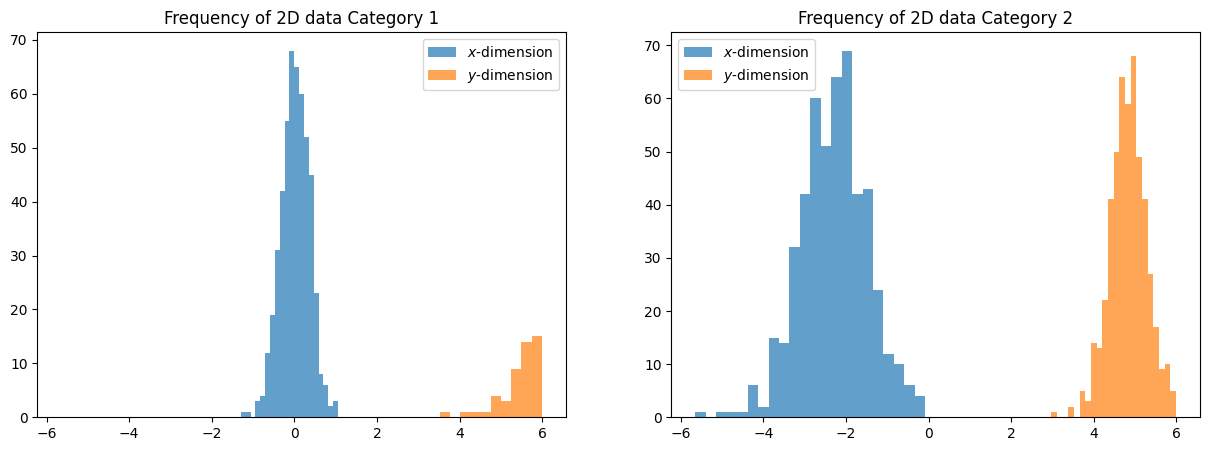

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

# AX 0
ax[0].hist(x=x0[:,0],
           bins='auto', 
           range=[x1.min(), x1.max()],
           label='$x$-dimension',
           alpha=0.7
)
ax[0].hist(x=x0[:,1],
           bins='auto', 
           range=[x1.min(), x1.max()],
           label='$y$-dimension',
           alpha=0.7
)
ax[0].legend()
ax[0].set_title('Frequency of 2D data Category 1')

ax[1].hist(x=x1[:,0],
           bins='auto', 
           range=[x1.min(), x1.max()],
           label='$x$-dimension',
           alpha=0.7
)

ax[1].hist(x=x1[:,1],
           bins='auto', 
           range=[x1.min(), x1.max()],
           label='$y$-dimension',
           alpha=0.7
)
ax[1].legend()
ax[1].set_title('Frequency of 2D data Category 2')

plt.show()

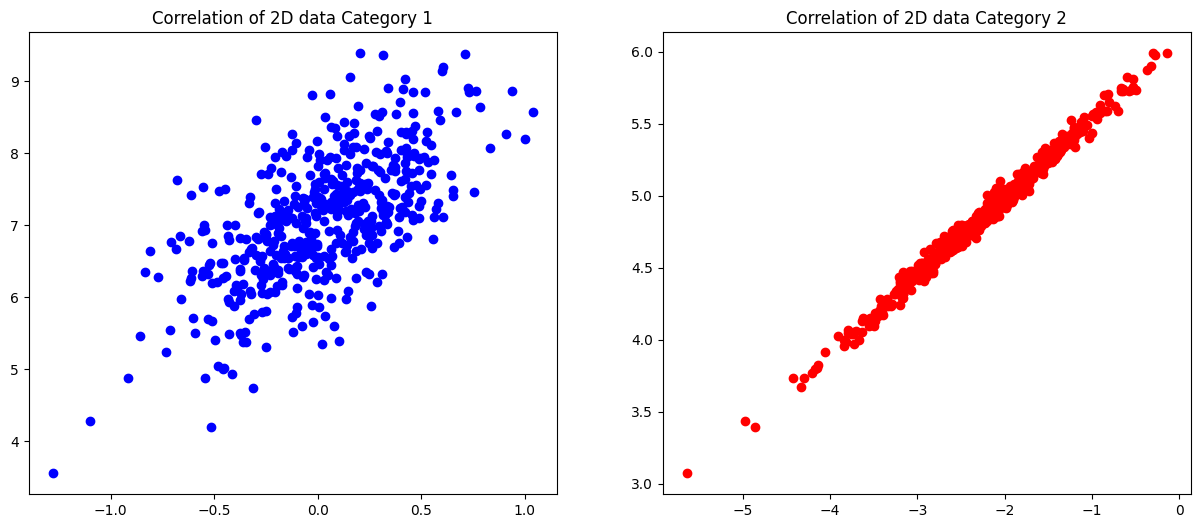

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,6))

ax[0].scatter(x=x0[:,0], y=x0[:,1], c='blue')
ax[0].set_title('Correlation of 2D data Category 1')

ax[1].scatter(x=x1[:,0], y=x1[:,1], c='red')
ax[1].set_title('Correlation of 2D data Category 2')

plt.show()


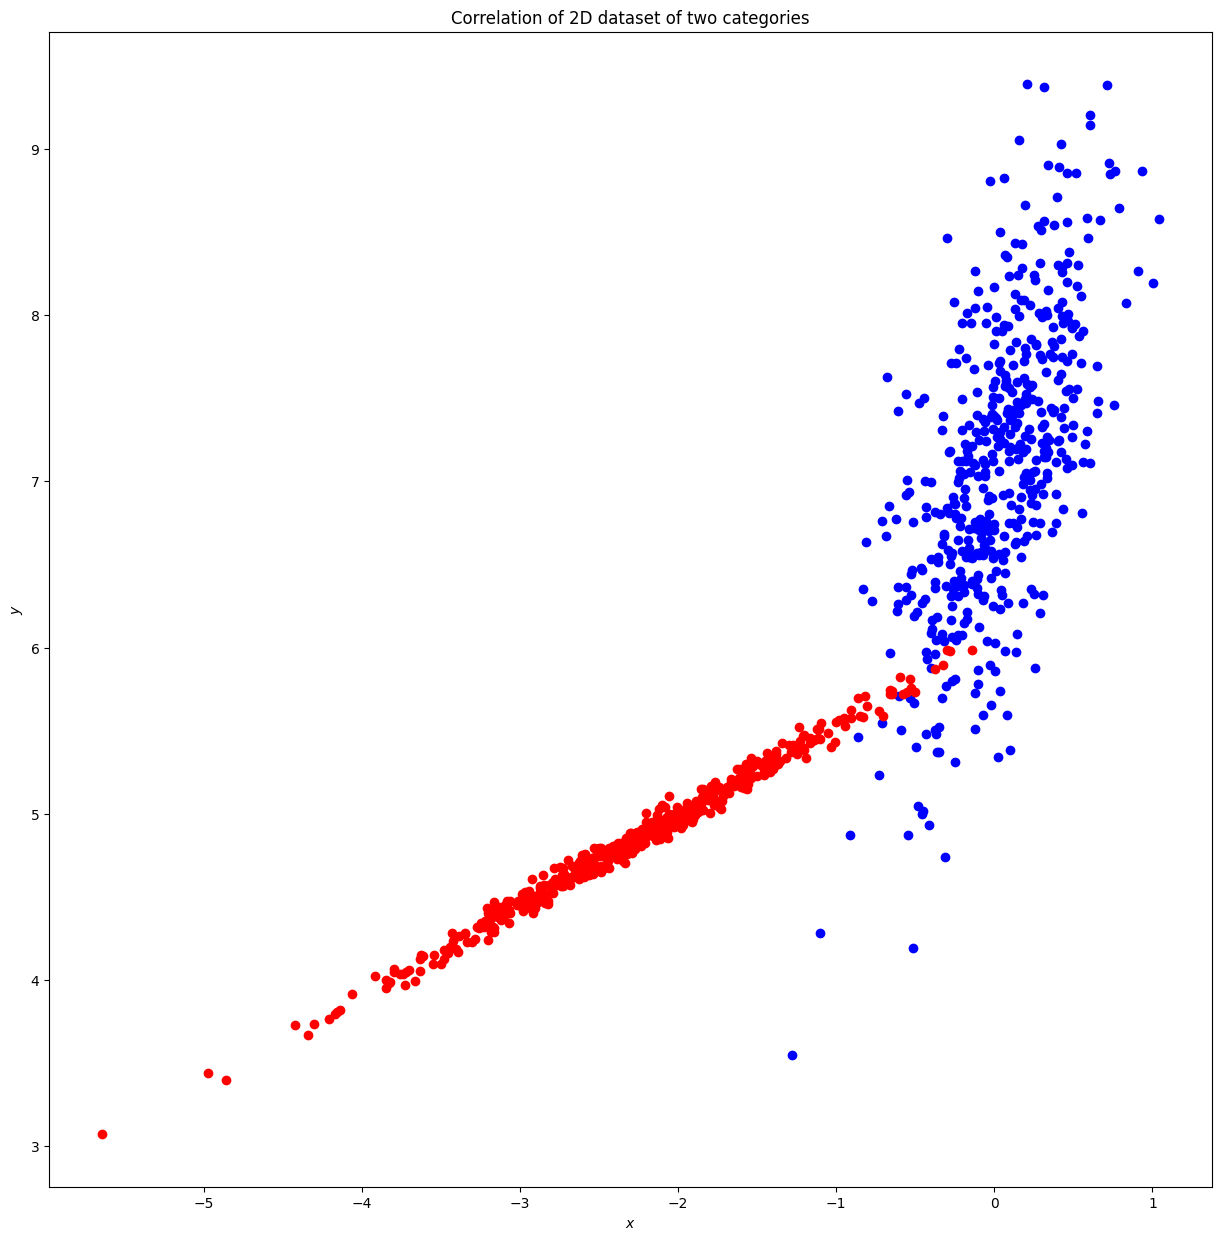

In [12]:
fig, ax = plt.subplots(figsize=(15,15))

ax.scatter(x=x0[:,0], y=x0[:,1], c='blue', label='Category 1')
ax.scatter(x=x1[:,0], y=x1[:,1], c='red', label='Category 2')
ax.set_title('Correlation of 2D dataset of two categories')
ax.set_ylabel('$y$')
ax.set_xlabel('$x$')
plt.show()

3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

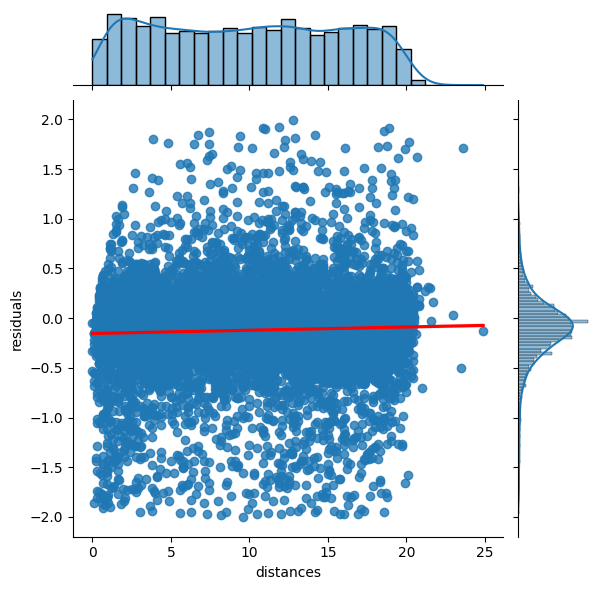

In [13]:
import seaborn as sns
import pandas as pd

file_name = "/Users/Filippo/Documents/UniPd/LABORATORY OF COMPUTATIONAL PHYSICS (MOD. A)/LaboratoryOfComputationalPhysics_Y7/residuals_261.npy"

a = np.load(file=file_name, allow_pickle=True)
datar = pd.DataFrame(a.item())
datar_c = datar[abs(datar['residuals'])<2]

res = datar_c['residuals']
dist = datar_c['distances']
reg = sts.linregress(x=dist, y=res)

sns.jointplot(data=datar_c, x='distances', y='residuals', kind='reg', line_kws=dict(color="r"))

In [14]:
#Fill 3 numpy arrays
#   x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
#   y, the mean values of the "residuals", estimated in slices (bins) of "distance"
#   erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
N = len(datar_c['distances'])
num_bins = int(np.sqrt(N))
n, bin_edges = np.histogram(dist, bins=np.arange(0,21, 1/num_bins+1))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
x = np.array(bin_centers)


y_means = []    # mean values of "residuals" for each bin
y_stds = []      # std of res for each bin

# for loop in which:
#   1)  we take all the dist-values contained in a bin 
#           for i in range(len(bin_edges)):
#               create a mask to select
#               all values greater than the first binned value
#               datar_c['distances'] >= bin_edges[i]
#               all values smaller than the last binned value for that bin
#               datar_c['distances'] < bin_edges[i+1] 
#   2)  filter in selected values from the residuals column 
#       take the mean and std and append to lists

for i in range(len(bin_edges) - 1):
    bin_mask = (datar_c['distances'] >= bin_edges[i]) & (datar_c['distances'] < bin_edges[i + 1])
    bin_data = datar_c['residuals'][bin_mask]

    y_means.append(bin_data.mean())
    y_stds.append(bin_data.std())

y = np.array(y_means)
erry = np.array(y_stds)

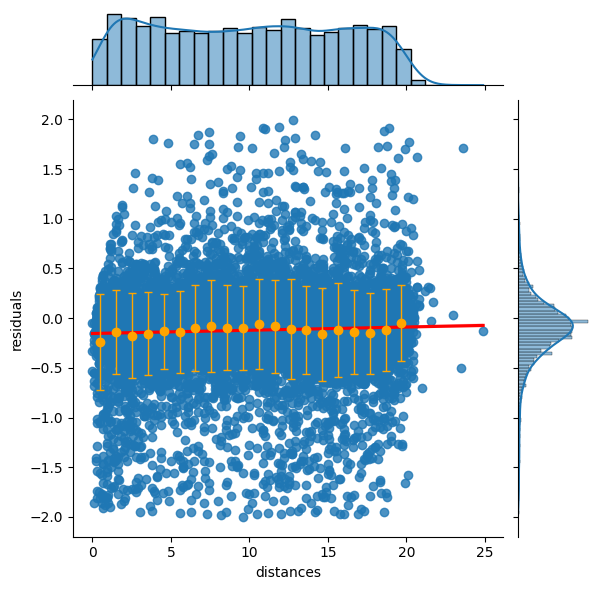

In [15]:
#   Plot the profile plot on top of the scatter plot

sns.jointplot(data=datar_c, x='distances', y='residuals', kind='reg', line_kws=dict(color="r"))
plt.errorbar(x=x, y=y, yerr=erry, color='orange', capsize = 3, marker = 'o', lw = 0, elinewidth=1)
plt.show()